In [1]:
import sys
from pathlib import Path

# Add project root to sys.path (go up 2 levels from notebook to project root)
project_root = Path.cwd().parent.parent
if str(project_root) not in sys.path:
    sys.path.insert(0, str(project_root))

# Now import works
from src.research import (
    load_orders,
    build_trade_totals,
    compute_basic_stats,
    compute_win_loss_stats,
    compute_expectancy,
    classify_exit_reasons,
    compute_exit_type_stats,
    get_exit_hour_distribution,
    merge_market_data,
    compute_distribution_stats,
    get_worst_trades,
    get_best_trades,
    compute_range_bucketed_stats,
    compute_range_group_stats,
)

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import datetime as dt

In [2]:
orders = load_orders("../data/baseline_v1_orders_02_13_2026.csv", start_date="2022-04-01")
trades = build_trade_totals(orders)

/Users/jplatta/repos/trade_lab/src/research/backtest_loader.py:121: UserWarning: Converting to PeriodArray/Index representation will drop timezone information.
  trade_totals["month"] = trade_totals["exit_time"].dt.to_period("M")


## Returns

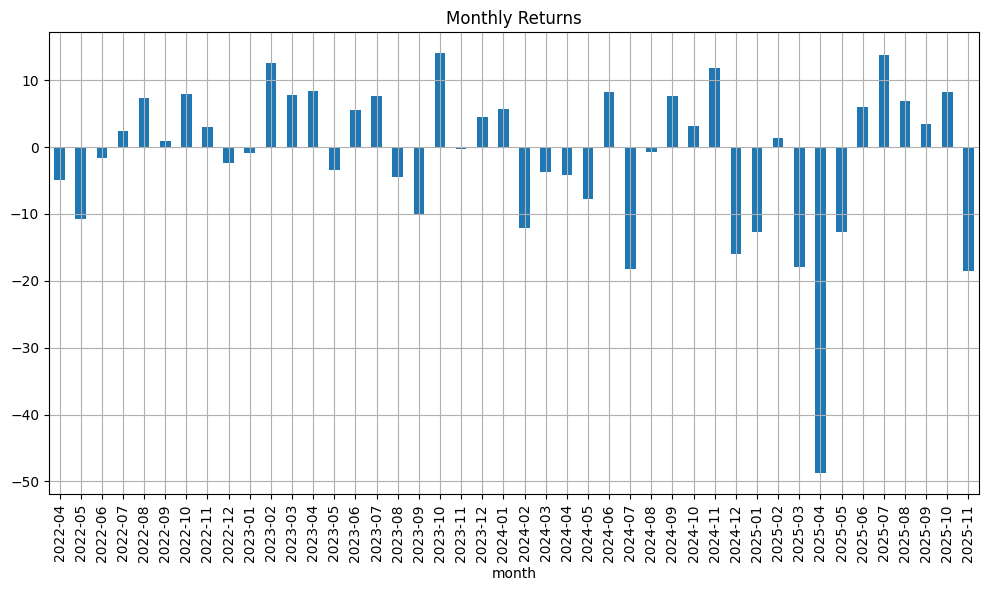

In [3]:
ax = (
    trades.groupby("month")["value"]
    .sum()
    .plot(kind="bar", figsize=(12, 6), title="Monthly Returns", grid=True)
)

## Stats

In [4]:
stats = compute_basic_stats(trades)
for k, v in stats.items():
    print(f"{k}: {v}")

mean_return: -0.07726638772663878
median_return: 0.8000000000000002
std_return: 2.520832043771451
min_return: -15.899999999999997
max_return: 2.0999999999999996
total_pnl: -55.400000000000006


In [5]:
win_loss_stats = compute_win_loss_stats(trades)
for k, v in win_loss_stats.items():
    print(f"{k}: {v}")

wins: 592
losses: 125
win_rate: 0.8256624825662483
avg_win: 0.8528716216216216
avg_loss: -4.4824
largest_win: 2.0999999999999996
largest_loss: -15.899999999999997


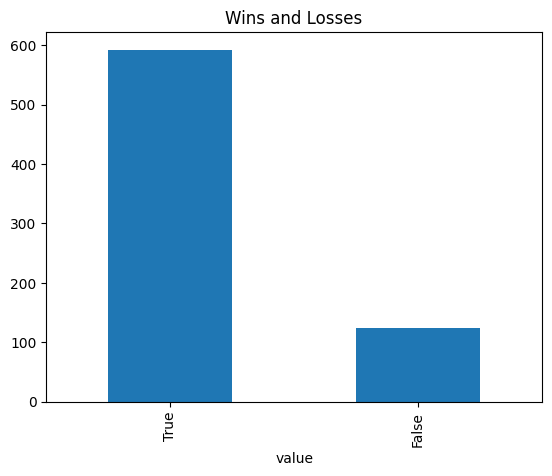

In [6]:
ax = trades["value"].gt(0).value_counts().plot(kind="bar", title="Wins and Losses")

In [7]:
expectancy = compute_expectancy(trades)
win_rate = expectancy["win_rate"]
print(expectancy)

{'expectancy': np.float64(-0.07726638772663863), 'win_rate': np.float64(0.8256624825662483), 'avg_win': np.float64(0.8528716216216216), 'avg_loss': np.float64(-4.4824)}


In [8]:
dist_stats = compute_distribution_stats(trades)
for k, v in dist_stats.items():
    print(f"{k}: {v}")

skew: -3.0774468142494635
kurtosis: 9.98373430059405
percentiles: {'p1': np.float64(-10.642000000000001), 'p5': np.float64(-6.049999999999999), 'p10': np.float64(-3.8500000000000005), 'p25': np.float64(0.5499999999999999), 'p50': np.float64(0.8000000000000002), 'p75': np.float64(0.9500000000000001), 'p90': np.float64(1.1), 'p95': np.float64(1.2), 'p99': np.float64(1.4420000000000015)}


## Tail Analysis

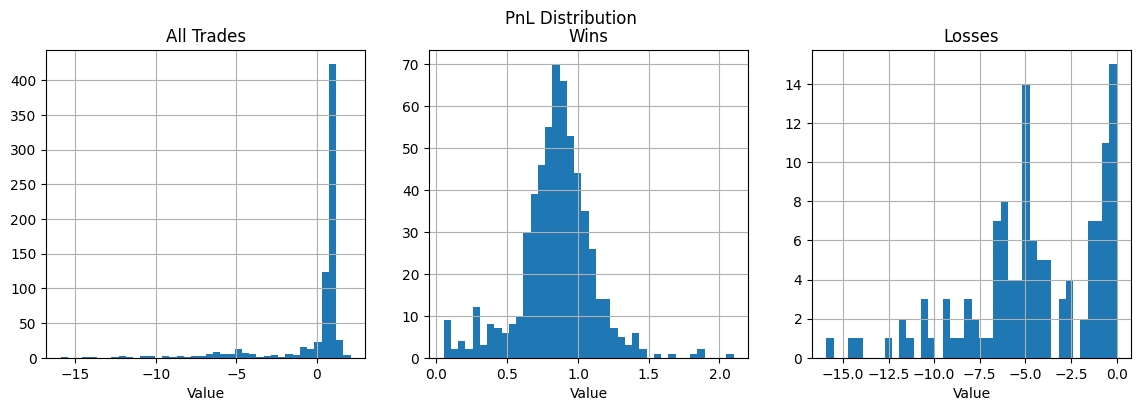

In [9]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4))

trades["value"].hist(bins=40, ax=axes[0])
trades[trades["value"] > 0.0]["value"].hist(bins=40, ax=axes[1])
trades[trades["value"] <= 0.0]["value"].hist(bins=40, ax=axes[2])

axes[0].set_title("All Trades")
axes[1].set_title("Wins")
axes[2].set_title("Losses")

for ax in axes:
    ax.set_xlabel("Value")

fig.suptitle("PnL Distribution", fontsize=12)
plt.savefig("trade_value_distribution.png", dpi=300, bbox_inches="tight")

In [10]:
worst_trades = get_worst_trades(trades)
best_trades = get_best_trades(trades)

In [11]:
worst_trades.iloc[:5][["value", "month"]]

,value,month
trade,,
595,-15.90,2025-04
442,-14.50,2024-07
205,-13.95,2023-05
543,-12.45,2025-01
276,-11.90,2023-09


In [12]:
returns = trades["value"].copy()

sorted_returns = returns.sort_values()  # ascending = worst first
total_pnl = returns.sum()
print("total pnl: ", total_pnl)

for n in [1, 5, 10]:
    worst_n = sorted_returns.head(n).sum()
    print(f"Worst {n} trades sum:", worst_n)
    print(f"Contribution % of total P&L:", worst_n / total_pnl)

total pnl:  -55.400000000000006
Worst 1 trades sum: -15.899999999999997
Contribution % of total P&L: 0.28700361010830316
Worst 5 trades sum: -68.69999999999999
Contribution % of total P&L: 1.2400722021660646
Worst 10 trades sum: -123.64999999999998
Contribution % of total P&L: 2.231949458483754


## Remove Worst Trades

In [13]:
less_worst_trades = trades.drop(trades.nsmallest(10, "value").index)

print("mean return: ", less_worst_trades["value"].mean())
print("std return: ", less_worst_trades["value"].std())
print("median return: ", less_worst_trades["value"].median())
print("---")

avg_win = less_worst_trades[less_worst_trades["value"] > 0]["value"].mean()
print("avg win: ", avg_win)
print("largest win: ", less_worst_trades["value"].max())
print("---")
avg_loss = less_worst_trades[less_worst_trades["value"] <= 0]["value"].mean()
print("avg loss: ", avg_loss)
print("largest loss: ", less_worst_trades["value"].min())
print("---")
expectancy = (win_rate * avg_win) + ((1.0 - win_rate) * avg_loss)
print("expectancy: ", expectancy)

mean return:  0.09653465346534654
std return:  2.0571470831403356
median return:  0.8000000000000003
---
avg win:  0.8528716216216216
largest win:  2.0999999999999996
---
avg loss:  -3.796956521739131
largest loss:  -10.250000000000002
---
expectancy:  0.04223212661451714


## Exit Conditions

In [14]:
trades_with_exits = classify_exit_reasons(trades)

In [15]:
trades_with_exits.head()

,exit_time,value,month,short_call_strike,short_put_strike,exit_reason
trade,,,,,,
0,2022-04-04 10:00:00-04:00,0.70,2022-04,4600.0,4460.0,prof_target_reached
1,2022-04-06 10:00:00-04:00,-5.90,2022-04,4615.0,4465.0,max_loss
2,2022-04-08 11:00:00-04:00,1.20,2022-04,4580.0,4425.0,prof_target_reached
3,2022-04-11 13:00:00-04:00,-1.55,2022-04,4580.0,4420.0,forced_exit
4,2022-04-13 10:00:00-04:00,0.75,2022-04,4480.0,4320.0,prof_target_reached


In [16]:
exit_stats = compute_exit_type_stats(trades_with_exits)
exit_stats

,count,win_rate,avg_pnl,std_pnl,total_pnl
exit_reason,,,,,
afternoon_prof,134,1.000000,0.690672,0.315583,92.55
forced_exit,77,0.272727,-1.370130,2.286376,-105.50
max_loss,69,0.000000,-6.411594,3.244103,-442.40
prof_target_reached,437,1.000000,0.915217,0.197381,399.95


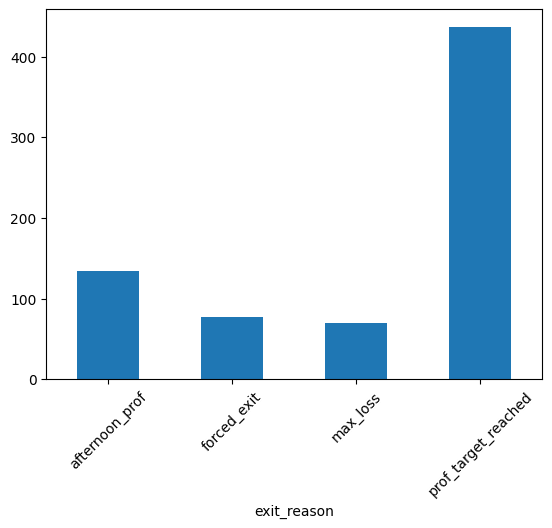

In [17]:
ax = exit_stats["count"].plot(kind="bar", rot=45)

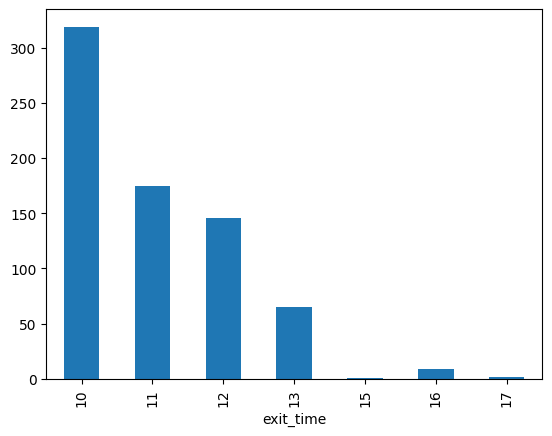

In [18]:
exit_hours = get_exit_hour_distribution(trades_with_exits)
ax = exit_hours.plot(kind="bar")

## SPX Range Analysis

In [19]:
trades_with_market = merge_market_data(trades_with_exits, "../data/SPX_daily_2022-2025.csv")

In [20]:
trades_with_market["value"]
returns = trades_with_market["value"].copy()
initial_capital = 50_000
position_size = 100
equity = initial_capital + (returns * position_size).cumsum()

In [21]:
df = trades_with_market.sort_values("exit_time").copy()

df["range_10d"] = df["range"].rolling(10, min_periods=5).mean()

mask = df["range_10d"] > 51.698
dates = df["exit_time"].dt.date

blocks = []
in_block = False
start_date = None

for i in range(len(df)):
    if mask.iloc[i] and not in_block:
        in_block = True
        start_date = dates.iloc[i]
    elif not mask.iloc[i] and in_block:
        end_date = dates.iloc[i - 1]
        blocks.append((start_date, end_date))
        in_block = False

if in_block:
    blocks.append((start_date, dates.iloc[-1]))

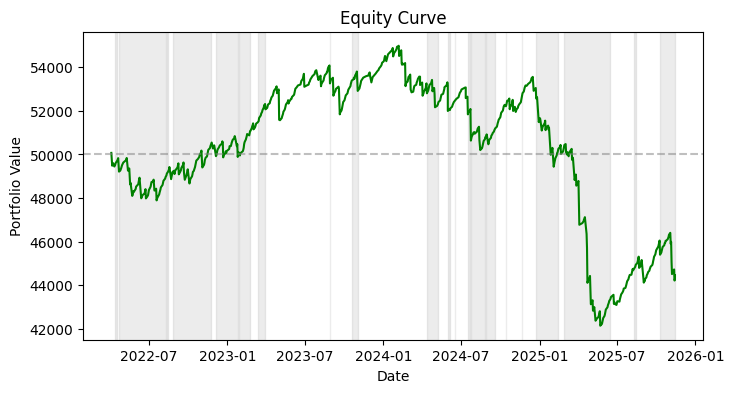

In [22]:
fig, ax = plt.subplots(figsize=(8, 4))

for start, end in blocks:
    ax.axvspan(
        start - dt.timedelta(days=0.5),
        end + dt.timedelta(days=0.5),
        color="gray",
        alpha=0.15,
        zorder=0,
    )

ax.plot(trades_with_market["exit_time"].dt.date, equity.values, label="Equity Curve", color="green")
ax.axhline(50000, linestyle="--", color="gray", alpha=0.5)
ax.set_ylabel("Portfolio Value")
ax.set_xlabel("Date")
ax.set_title("Equity Curve")

plt.savefig("equity_curve_spx_1dte.png")
plt.show()

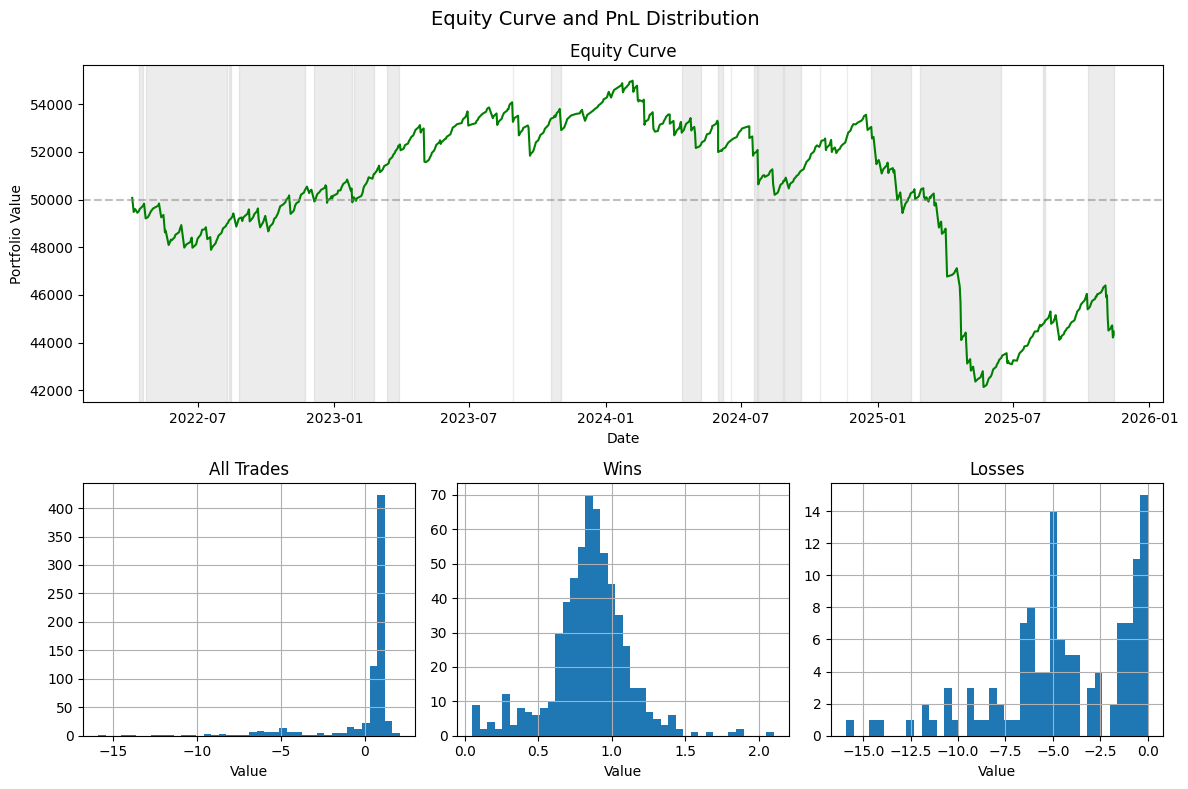

In [23]:
import matplotlib.pyplot as plt
import datetime as dt

# Create layout: 2 rows, 3 columns
fig = plt.figure(figsize=(12, 8))
gs = fig.add_gridspec(2, 3, height_ratios=[2, 1.5])

# -----------------------
# Top: Equity Curve (span all columns)
# -----------------------
ax_equity = fig.add_subplot(gs[0, :])

for start, end in blocks:
    ax_equity.axvspan(
        start - dt.timedelta(days=0.5),
        end + dt.timedelta(days=0.5),
        color="gray",
        alpha=0.15,
        zorder=0,
    )

ax_equity.plot(
    trades_with_market["exit_time"].dt.date, equity.values, label="Equity Curve", color="green"
)

ax_equity.axhline(50000, linestyle="--", color="gray", alpha=0.5)
ax_equity.set_ylabel("Portfolio Value")
ax_equity.set_xlabel("Date")
ax_equity.set_title("Equity Curve")

# -----------------------
# Bottom: PnL Distributions
# -----------------------
ax_all = fig.add_subplot(gs[1, 0])
ax_win = fig.add_subplot(gs[1, 1])
ax_loss = fig.add_subplot(gs[1, 2])

trades["value"].hist(bins=40, ax=ax_all)
trades[trades["value"] > 0.0]["value"].hist(bins=40, ax=ax_win)
trades[trades["value"] <= 0.0]["value"].hist(bins=40, ax=ax_loss)

ax_all.set_title("All Trades")
ax_win.set_title("Wins")
ax_loss.set_title("Losses")

for ax in [ax_all, ax_win, ax_loss]:
    ax.set_xlabel("Value")

fig.suptitle("Equity Curve and PnL Distribution", fontsize=14)
plt.tight_layout()
plt.savefig("equity_and_distribution.png", dpi=300, bbox_inches="tight")
plt.show()

In [24]:
range_grp_stats = compute_range_group_stats(trades_with_market, range_threshold=51.698)
range_grp_stats

,trade_count,win_rate,mean_pnl,avg_win_pnl,avg_loss,pct_max_loss_exits,total_pnl
range_group,,,,,,,
< 51.698,394,0.906091,0.489213,0.841457,-2.909459,0.045685,192.75
>= 51.698,323,0.727554,-0.768266,0.870213,-5.143750,0.157895,-248.15


In [25]:
range_stats = compute_range_bucketed_stats(trades_with_market)

In [28]:
range_stats

,value_count,value_win_rate,value_avg_pnl,range_avg_range
range_bucket,,,,
"(12.319, 23.396]",36,0.972222,0.761111,19.273056
"(23.396, 26.74]",36,0.916667,0.475000,25.282778
"(26.74, 29.462]",36,0.972222,0.730556,28.231111
"(29.462, 32.706]",36,0.944444,0.641667,30.968056
"(32.706, 34.89]",37,0.945946,0.747297,33.875135
"(34.89, 37.194]",34,0.882353,0.382353,35.777353
"(37.194, 39.702]",36,0.805556,0.123611,38.400556
"(39.702, 42.468]",36,0.916667,0.769444,41.045556
"(42.468, 45.374]",36,0.888889,0.408333,44.018889


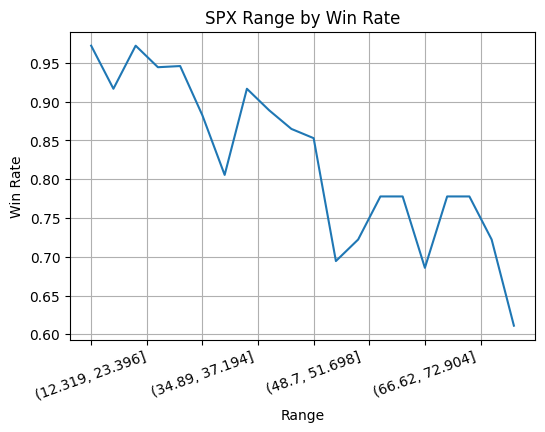

In [29]:
ax = range_stats["value_win_rate"].plot(
    rot=20,
    figsize=(6, 4),
    ylabel="Win Rate",
    xlabel="Range",
    grid=True,
    title="SPX Range by Win Rate",
)

plt.savefig("range_by_win_rate.png", bbox_inches="tight")

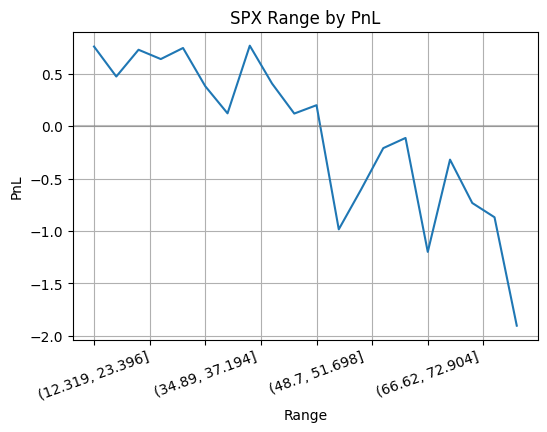

In [53]:
ax = range_stats["value_avg_pnl"].plot(
    rot=20, figsize=(6, 4), ylabel="PnL", xlabel="Range", title="SPX Range by PnL", grid=True
)
ax.axhline(y=0, color="gray", alpha=0.5)

plt.savefig("range_by_pnl.png", bbox_inches="tight")

## Forced Exit Analysis

In [54]:
forced_exits = trades_with_market[trades_with_market["exit_reason"] == "forced_exit"]
forced_exits.head()

,exit_time,value,month,short_call_strike,short_put_strike,exit_reason,date,open,high,low,close,range
3,2022-04-11 13:00:00-04:00,-1.55,2022-04,4580.0,4420.0,forced_exit,2022-04-11,4462.64,4464.35,4408.38,4412.53,55.97
23,2022-05-27 13:00:00-04:00,-0.30,2022-05,4150.0,3960.0,forced_exit,2022-05-27,4077.43,4158.49,4077.43,4158.24,81.06
47,2022-07-19 13:00:00-04:00,-5.35,2022-07,3920.0,3765.0,forced_exit,2022-07-19,3860.73,3939.81,3860.73,3936.69,79.08
62,2022-08-17 13:00:00-04:00,1.00,2022-08,4360.0,4230.0,forced_exit,2022-08-17,4280.40,4302.18,4253.08,4274.04,49.10
70,2022-08-30 13:00:00-04:00,-1.50,2022-08,4125.0,3965.0,forced_exit,2022-08-30,4041.25,4044.98,3965.21,3986.16,79.77


In [55]:
win_mask = (forced_exits["short_call_strike"] > forced_exits["close"]) & (
    forced_exits["short_put_strike"] < forced_exits["close"]
)

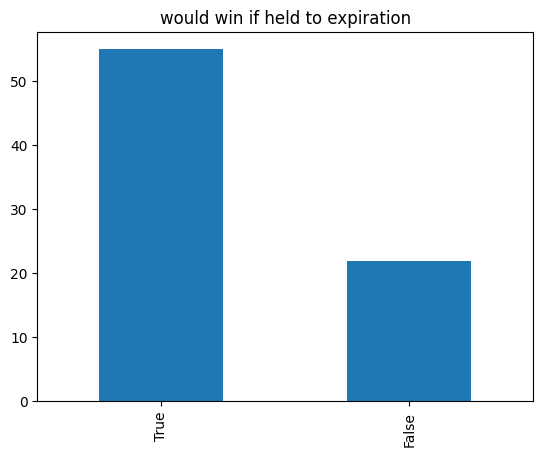

In [56]:
ax = win_mask.value_counts().plot(kind="bar", title="would win if held to expiration")

## Max Loss Trades Analysis

In [57]:
max_loss_trades = trades_with_market[trades_with_market["exit_reason"] == "max_loss"]
max_loss_trades.head()

,exit_time,value,month,short_call_strike,short_put_strike,exit_reason,date,open,high,low,close,range
1,2022-04-06 10:00:00-04:00,-5.9,2022-04,4615.0,4465.0,max_loss,2022-04-06,4494.17,4503.94,4450.04,4481.15,53.90
8,2022-04-22 12:00:00-04:00,-6.2,2022-04,4495.0,4315.0,max_loss,2022-04-22,4385.83,4385.83,4267.62,4271.78,118.21
15,2022-05-13 10:00:00-04:00,-5.8,2022-05,4010.0,3720.0,max_loss,2022-05-13,3963.90,4038.88,3963.90,4023.89,74.98
17,2022-05-18 12:00:00-04:00,-7.3,2022-05,4170.0,3970.0,max_loss,2022-05-18,4051.98,4051.98,3911.91,3923.68,140.07
19,2022-05-23 12:00:00-04:00,-6.0,2022-05,3975.0,3700.0,max_loss,2022-05-23,3919.42,3981.88,3909.04,3973.75,72.84


In [58]:
win_mask = (max_loss_trades["short_call_strike"] > max_loss_trades["close"]) & (
    max_loss_trades["short_put_strike"] < max_loss_trades["close"]
)
loss_mask = (max_loss_trades["short_call_strike"] < max_loss_trades["close"]) | (
    max_loss_trades["short_put_strike"] > max_loss_trades["close"]
)

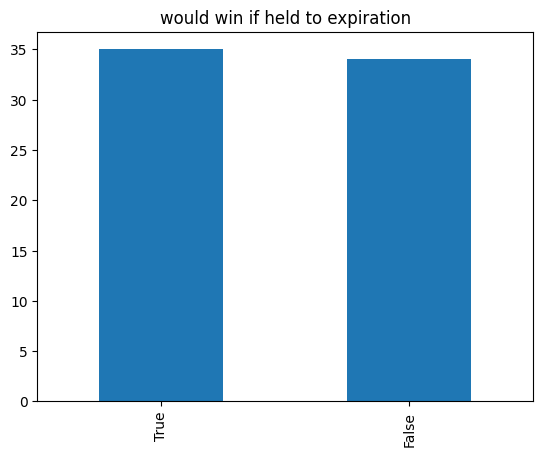

In [59]:
ax = win_mask.value_counts().plot(kind="bar", title="would win if held to expiration")

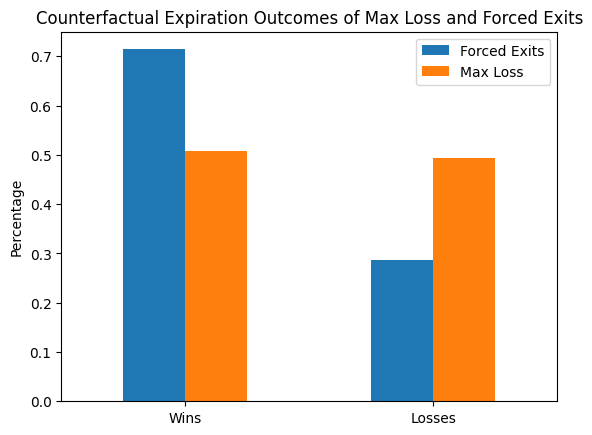

In [60]:
forced_exits_win_mask = (forced_exits["short_call_strike"] > forced_exits["close"]) & (
    forced_exits["short_put_strike"] < forced_exits["close"]
)
max_loss_win_mask = (max_loss_trades["short_call_strike"] > max_loss_trades["close"]) & (
    max_loss_trades["short_put_strike"] < max_loss_trades["close"]
)

forced_exits_win_mask.value_counts().plot(
    kind="bar", ax=ax, alpha=0.2, label="Forced Exits", color="yellow"
)
max_loss_win_mask.value_counts().plot(kind="bar", ax=ax, alpha=0.6, label="Max Loss")

counts = pd.DataFrame(
    {
        "Forced Exits": forced_exits_win_mask.value_counts(normalize=True),
        "Max Loss": max_loss_win_mask.value_counts(normalize=True),
    }
).fillna(0)
ax = counts.plot(
    kind="bar", title="Counterfactual Expiration Outcomes of Max Loss and Forced Exits"
)
ax.set_ylabel("Percentage")
ax.set_xticklabels(["Wins", "Losses"], rotation=0)

plt.savefig("counterfactual_outcomes.png")

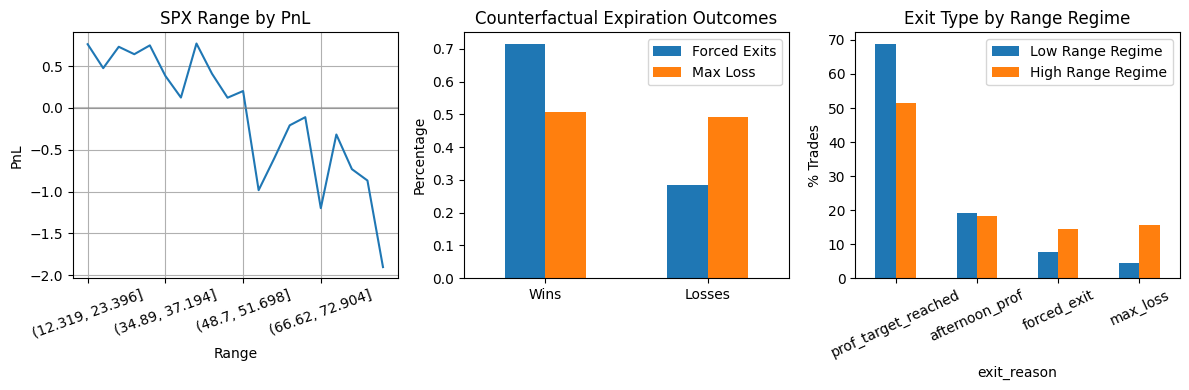

In [64]:
import matplotlib.pyplot as plt
import pandas as pd

# Create figure with 2 horizontal subplots
fig, axes = plt.subplots(1, 3, figsize=(12, 4))

# -----------------------
# Left plot: Range by PnL
# -----------------------
range_stats["value_avg_pnl"].plot(
    ax=axes[0], rot=20, ylabel="PnL", xlabel="Range", title="SPX Range by PnL", grid=True
)
axes[0].axhline(y=0, color="gray", alpha=0.5)

# ---------------------------------------------
# Right plot: Counterfactual Expiration Outcomes
# ---------------------------------------------
forced_exits_win_mask = (forced_exits["short_call_strike"] > forced_exits["close"]) & (
    forced_exits["short_put_strike"] < forced_exits["close"]
)

max_loss_win_mask = (max_loss_trades["short_call_strike"] > max_loss_trades["close"]) & (
    max_loss_trades["short_put_strike"] < max_loss_trades["close"]
)

counts = pd.DataFrame(
    {
        "Forced Exits": forced_exits_win_mask.value_counts(normalize=True),
        "Max Loss": max_loss_win_mask.value_counts(normalize=True),
    }
).fillna(0)

counts.plot(kind="bar", ax=axes[1], title="Counterfactual Expiration Outcomes")

axes[1].set_ylabel("Percentage")
axes[1].set_xticklabels(["Wins", "Losses"], rotation=0)

## Chart 3

regime_a_mask = trades_with_market["range"] < 51.698
regime_a = trades_with_market[regime_a_mask]
regime_b_mask = trades_with_market["range"] >= 51.698
regime_b = trades_with_market[regime_b_mask]

counts_a = regime_a["exit_reason"].value_counts(normalize=True)
counts_b = regime_b["exit_reason"].value_counts(normalize=True)

# Combine into one DataFrame
combined = (
    pd.concat([counts_a, counts_b], axis=1, keys=["Low Range Regime", "High Range Regime"]).fillna(
        0
    )
    * 100
)

# Plot side-by-side bars
combined.plot(kind="bar", rot=25, ylabel="% Trades", ax=axes[2], title="Exit Type by Range Regime")

plt.tight_layout()
plt.savefig("range_pnl_counterfact_exp_regime_exit_types.png", bbox_inches="tight")
plt.show()

In [48]:
win_mask.value_counts()

True     648
False     69
Name: count, dtype: int64

In [59]:
trades_with_market.shape

(717, 12)

In [72]:
would_win_removed = trades_with_market.loc[
    ~trades_with_market.index.isin(max_loss_trades[win_mask].index)
]
would_win_removed.shape

(682, 12)

In [73]:
win_loss_stats = compute_win_loss_stats(would_win_removed)
for k, v in win_loss_stats.items():
    print(f"{k}: {v}")

wins: 592
losses: 90
win_rate: 0.8680351906158358
avg_win: 0.8528716216216216
avg_loss: -4.150555555555556
largest_win: 2.0999999999999996
largest_loss: -14.500000000000004


In [74]:
expectancy = compute_expectancy(would_win_removed)
print(expectancy)

{'expectancy': np.float64(0.19259530791788848), 'win_rate': np.float64(0.8680351906158358), 'avg_win': np.float64(0.8528716216216216), 'avg_loss': np.float64(-4.150555555555556)}
